# **Dados e Aprendizagem Automática** 

## **Random Forest -  Tratamento 4 com Grid**
Aplicação de tratamento 4 e modelação utilizando Random Forest com Grid Search.

**Imports necessários para este teste**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

%matplotlib inline

### **Preparation**
**Load the CSVs**

In [2]:
df_train = pd.read_csv('../../Datasets/training_data.csv', encoding='latin-1')
df_test = pd.read_csv('../../Datasets/test_data.csv', encoding='latin-1')

print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)

Train shape: (6812, 14)
Test shape: (1500, 13)


**Feature Engineering (Extração da data)**

In [3]:
def extract_date_features(df):
    df['record_date'] = pd.to_datetime(df['record_date'])
    df['hour'] = df['record_date'].dt.hour
    df['day_of_week'] = df['record_date'].dt.dayofweek # Monday=0, Sunday=6
    df['month'] = df['record_date'].dt.month
    
    # Create "Weekend" feature
    df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
    
    # Create "Rush Hour" feature (7 da manhã até às 9 da manhã e 4 da tarde ate às 7 da tarde, podemos brincar com estas horas)
    df['is_rush_hour'] = df['hour'].apply(lambda x: 1 if (7 <= x <= 9) or (16 <= x <= 19) else 0)
    
    return df.drop(columns=['record_date'])

df_train = extract_date_features(df_train)
df_test = extract_date_features(df_test)

**Missing Values e Valores Incorretos**

In [4]:
def clean_categorical_text(df):

    # Primeiro "limpamos" a coluna 'AVERAGE CLOUDINESS'
    correcoes_erros = {
        'cï¿½u': 'ceu',      # erro especifico
        'c\u00e9u': 'ceu', # é
        'c\u00fa': 'ceu',  # ú
        'c\u00fau': 'ceu', 
        'céu': 'ceu'
    }
    # regex=True permite substituir apenas parte da frase (ex: "cï¿½u claro" -> "ceu claro")
    df['AVERAGE_CLOUDINESS'] = df['AVERAGE_CLOUDINESS'].astype(str).replace(correcoes_erros, regex=True)

    cloud_map = {
        'ceu claro': 'ceu_claro',
        'ceu limpo': 'ceu_claro',

        'ceu pouco nublado': 'pouco_nublado',
        'nuvens dispersas': 'pouco_nublado',
        'algumas nuvens': 'pouco_nublado',

        'nuvens quebrados': 'nublado', 
        'nuvens quebradas': 'nublado',
        'tempo nublado': 'nublado',
        'nublado': 'nublado',
    }
    df['AVERAGE_CLOUDINESS'] = df['AVERAGE_CLOUDINESS'].astype(str).replace(cloud_map, regex=True)
    # Tratamos também dos seus missing values
    df['AVERAGE_CLOUDINESS'] = df['AVERAGE_CLOUDINESS'].replace('nan', 'unknown_cloudiness')
    
    # Depois "limpamos" também a coluna da "AVERAGE RAIN"
    rain_map = {
        'chuva fraca': 'chuva_fraca',
        'chuva leve': 'chuva_fraca',
        'aguaceiros fracos': 'chuva_fraca',
        'chuvisco fraco': 'chuva_fraca',
        'chuvisco e chuva fraca': 'chuva_fraca',
        'trovoada com chuva leve': 'chuva_fraca', 

        'chuva moderada': 'chuva_moderada',
        'chuva': 'chuva_moderada',
        'aguaceiros': 'chuva_moderada',
        'trovoada com chuva': 'chuva_moderada',

        'chuva forte': 'chuva_forte',
        'chuva de intensidade pesada': 'chuva_forte',
        'chuva de intensidade pesado': 'chuva_forte'
    }
    df['AVERAGE_RAIN'] = df['AVERAGE_RAIN'].replace(rain_map)
    # Tratamos também dos seus missing values
    df['AVERAGE_RAIN'] = df['AVERAGE_RAIN'].fillna('no_rain')
    
    #df["LUMINOSITY"] = df_train["LUMINOSITY"].replace("LOW_LIGHT", "LIGHT")
    
    return df

df_train = clean_categorical_text(df_train)
df_test = clean_categorical_text(df_test)

In [5]:
df_train["AVERAGE_SPEED_DIFF"] = df_train["AVERAGE_SPEED_DIFF"].fillna("None")

**Verificação dos valores dessas colunas agora**

In [6]:
df_test['AVERAGE_CLOUDINESS'].value_counts()

AVERAGE_CLOUDINESS
unknown_cloudiness    599
ceu_claro             372
pouco_nublado         301
nublado               228
Name: count, dtype: int64

In [7]:
df_test['AVERAGE_RAIN'].value_counts()

AVERAGE_RAIN
no_rain           1360
chuva_fraca         93
chuva_moderada      47
Name: count, dtype: int64

**Drop de Colunas Redundates** 

Considera-mo-las redundantes devido a 'CITY_NAME' conter um valor constante ("Porto") e 'AVERAGE_PRECIPITATION' consistir quase apenas em zeros.

In [8]:
cols_to_drop = ['city_name', 'AVERAGE_PRECIPITATION']
df_train = df_train.drop(columns=cols_to_drop)
df_test = df_test.drop(columns=cols_to_drop)

**Handling categoric data**

In [9]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder

In [10]:
"""
AVERAGE_RAIN
"""

le_rain = LabelEncoder()
df_train["AVERAGE_RAIN"] = le_rain.fit_transform(df_train["AVERAGE_RAIN"])
df_test["AVERAGE_RAIN"] = le_rain.transform(df_test["AVERAGE_RAIN"])

In [11]:
"""
AVERAGE_CLOUDINESS
"""
le_cloud = LabelEncoder()
df_train["AVERAGE_CLOUDINESS"] = le_cloud.fit_transform(df_train["AVERAGE_CLOUDINESS"])
df_test["AVERAGE_CLOUDINESS"] = le_cloud.transform(df_test["AVERAGE_CLOUDINESS"])

In [12]:
"""
LUMINOSITY
"""
le_lu = LabelEncoder()
df_train["LUMINOSITY"] = le_lu.fit_transform(df_train["LUMINOSITY"])
df_test["LUMINOSITY"] = le_lu.transform(df_test["LUMINOSITY"])

In [13]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6812 entries, 0 to 6811
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   AVERAGE_SPEED_DIFF       6812 non-null   object 
 1   AVERAGE_FREE_FLOW_SPEED  6812 non-null   float64
 2   AVERAGE_TIME_DIFF        6812 non-null   float64
 3   AVERAGE_FREE_FLOW_TIME   6812 non-null   float64
 4   LUMINOSITY               6812 non-null   int64  
 5   AVERAGE_TEMPERATURE      6812 non-null   float64
 6   AVERAGE_ATMOSP_PRESSURE  6812 non-null   float64
 7   AVERAGE_HUMIDITY         6812 non-null   float64
 8   AVERAGE_WIND_SPEED       6812 non-null   float64
 9   AVERAGE_CLOUDINESS       6812 non-null   int64  
 10  AVERAGE_RAIN             6812 non-null   int64  
 11  hour                     6812 non-null   int32  
 12  day_of_week              6812 non-null   int32  
 13  month                    6812 non-null   int32  
 14  is_weekend              

In [14]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   AVERAGE_FREE_FLOW_SPEED  1500 non-null   float64
 1   AVERAGE_TIME_DIFF        1500 non-null   float64
 2   AVERAGE_FREE_FLOW_TIME   1500 non-null   float64
 3   LUMINOSITY               1500 non-null   int64  
 4   AVERAGE_TEMPERATURE      1500 non-null   float64
 5   AVERAGE_ATMOSP_PRESSURE  1500 non-null   float64
 6   AVERAGE_HUMIDITY         1500 non-null   float64
 7   AVERAGE_WIND_SPEED       1500 non-null   float64
 8   AVERAGE_CLOUDINESS       1500 non-null   int64  
 9   AVERAGE_RAIN             1500 non-null   int64  
 10  hour                     1500 non-null   int32  
 11  day_of_week              1500 non-null   int32  
 12  month                    1500 non-null   int32  
 13  is_weekend               1500 non-null   int64  
 14  is_rush_hour            

**Outliers**

In [15]:
numeric_cols = df_train.select_dtypes(include=['int32','int64', 'float64']).columns


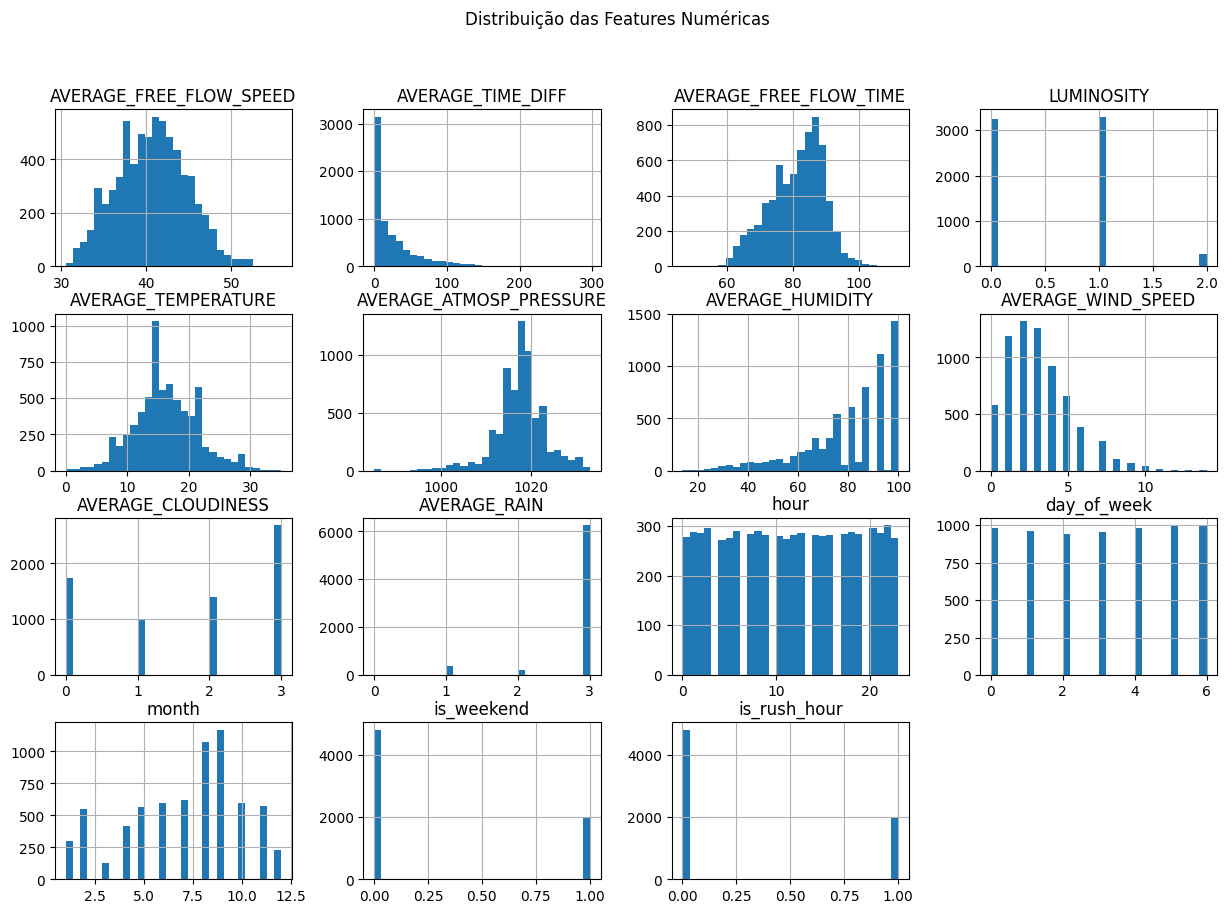

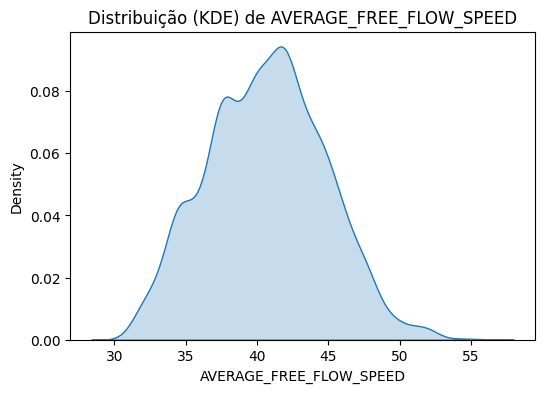

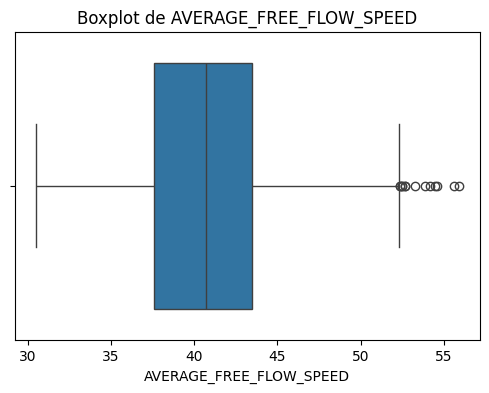

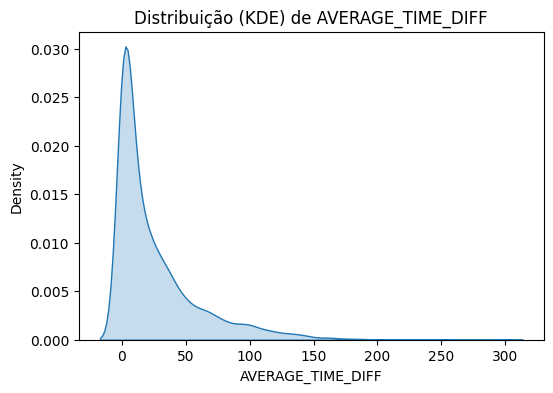

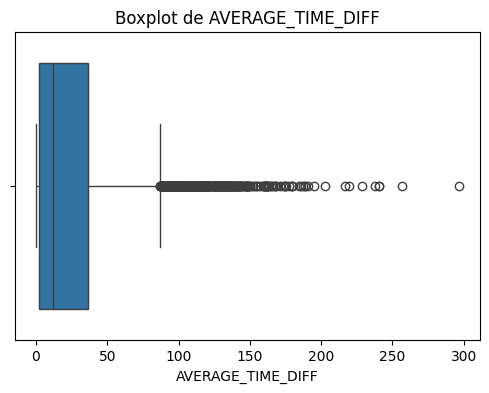

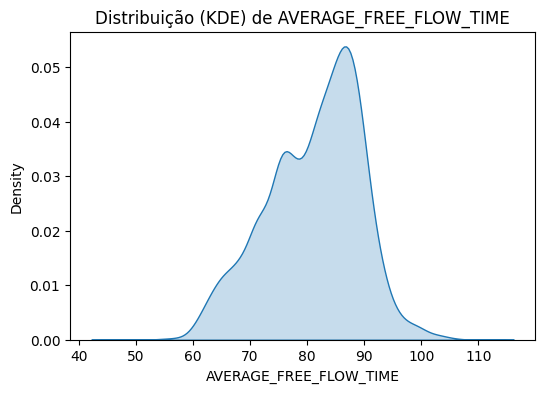

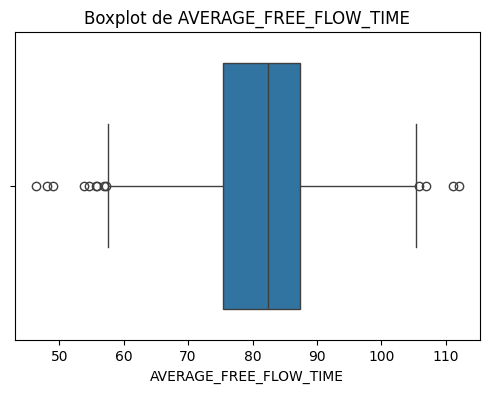

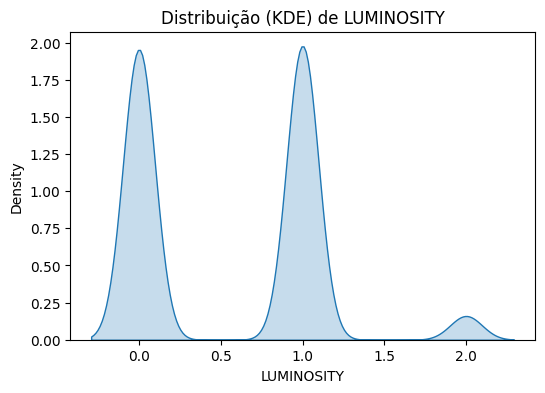

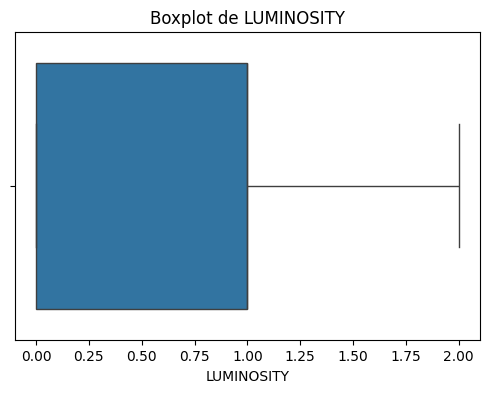

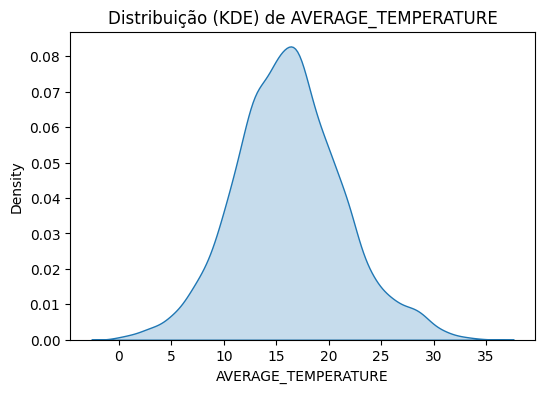

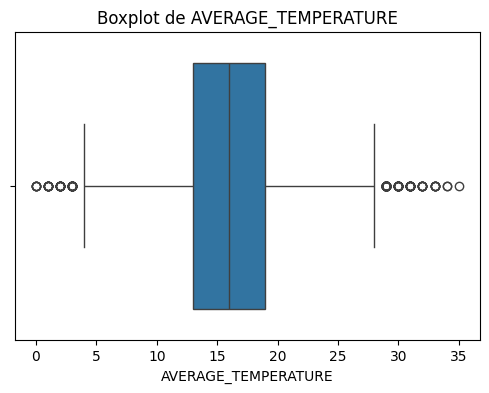

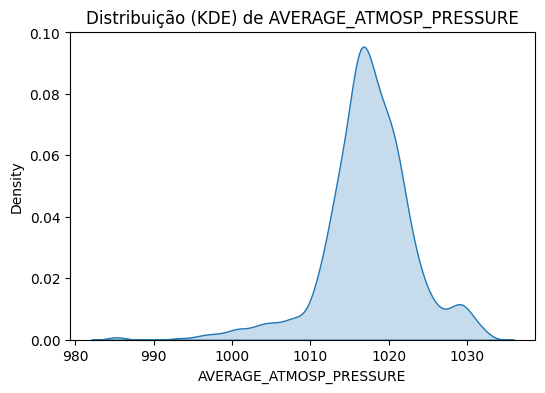

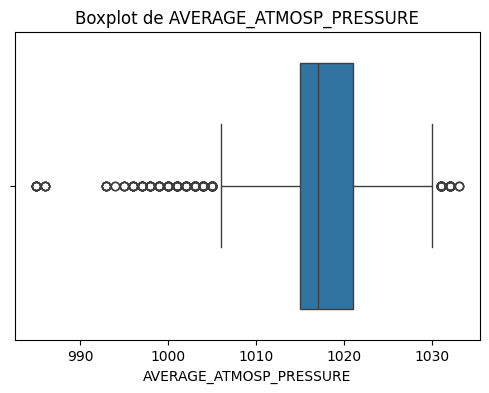

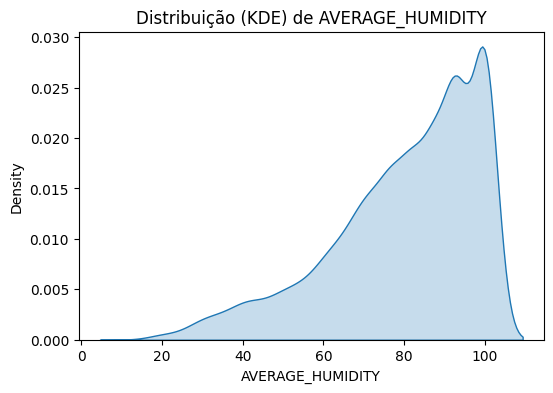

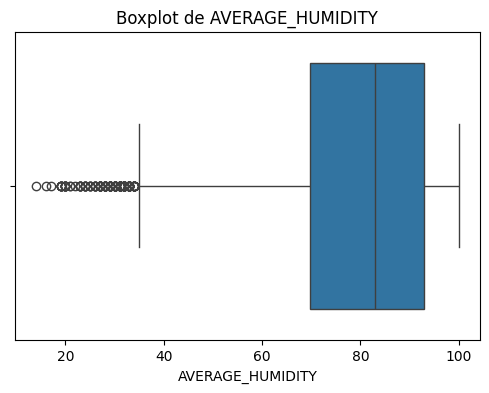

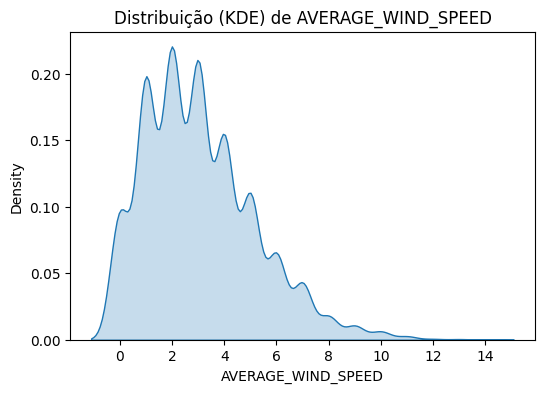

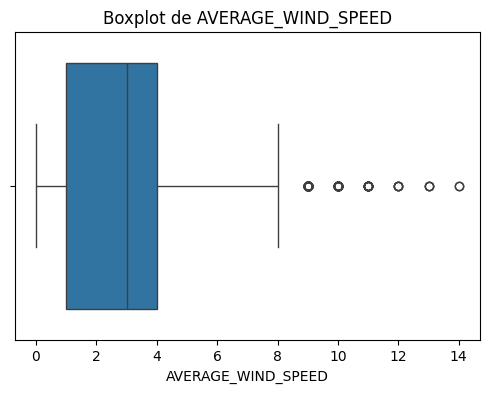

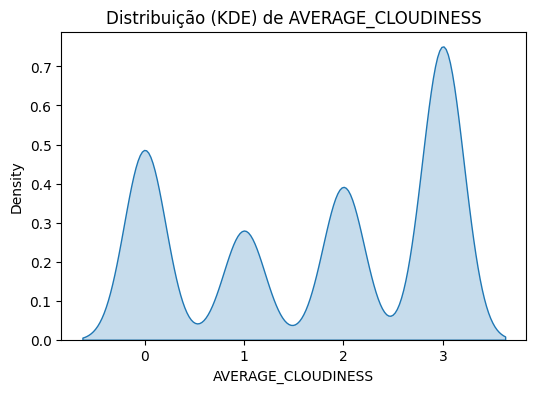

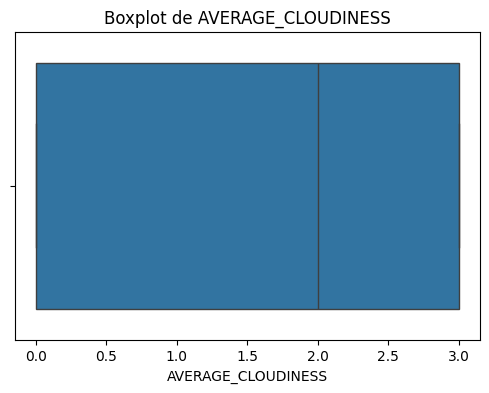

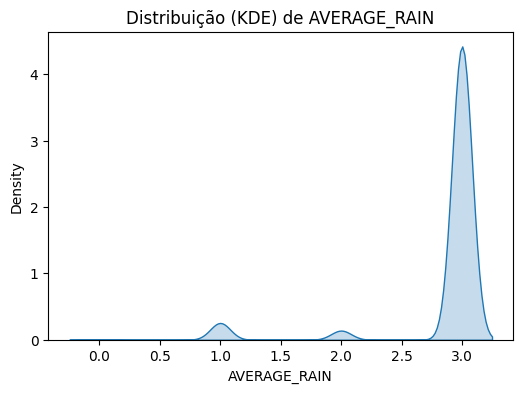

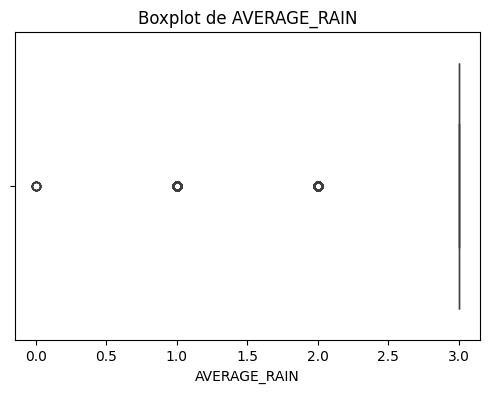

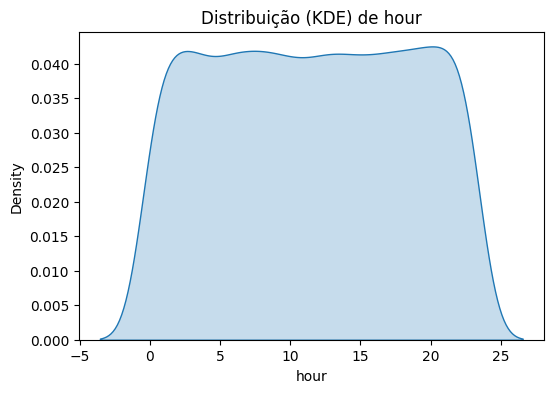

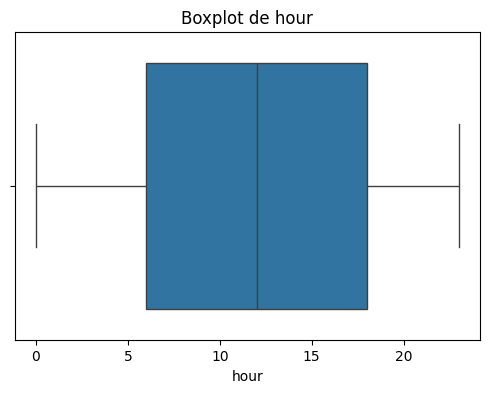

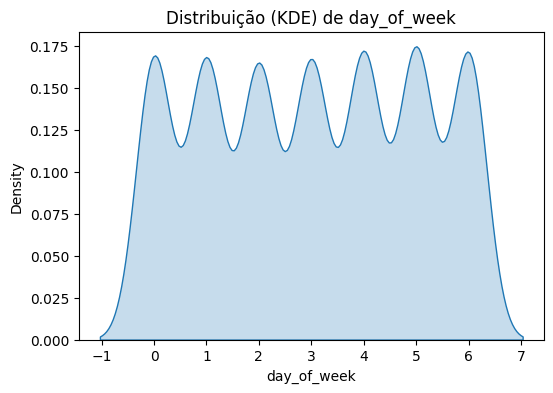

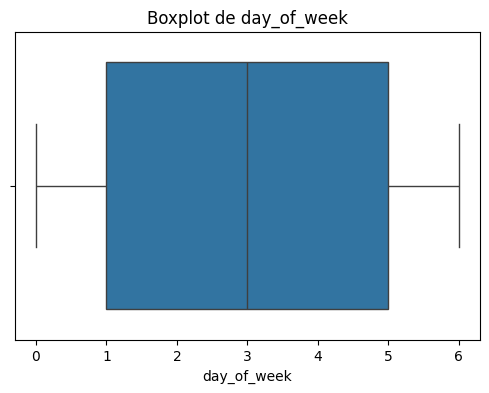

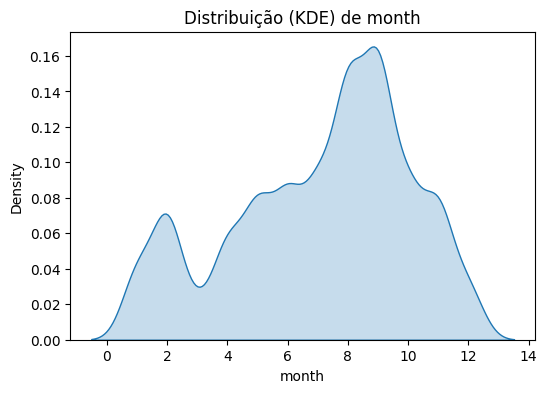

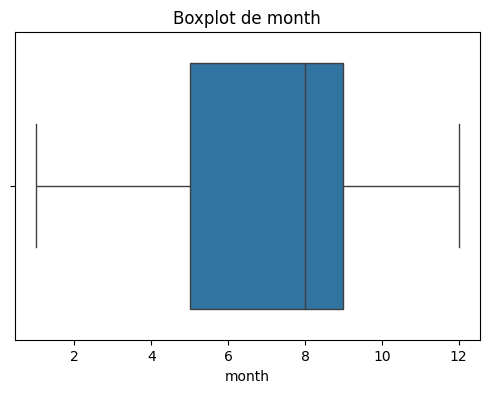

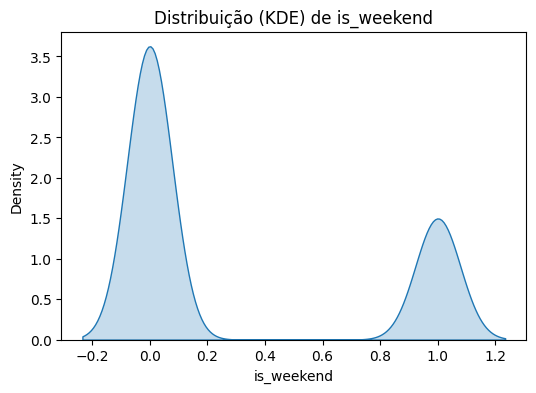

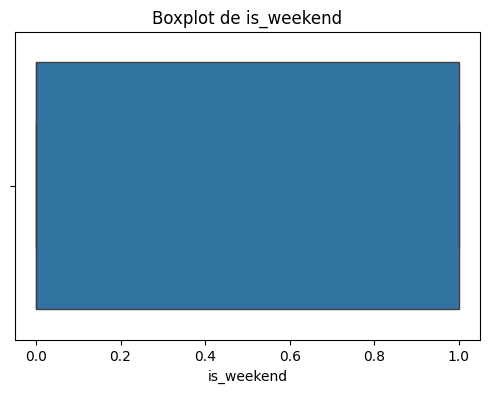

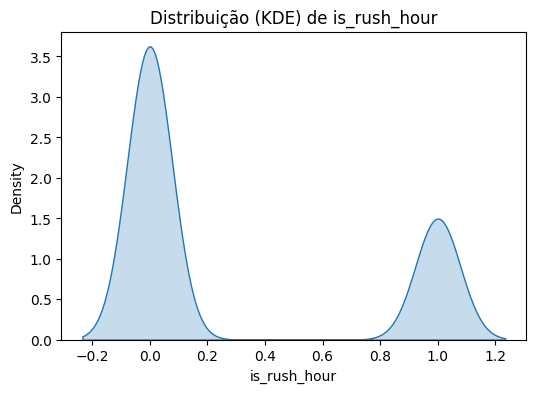

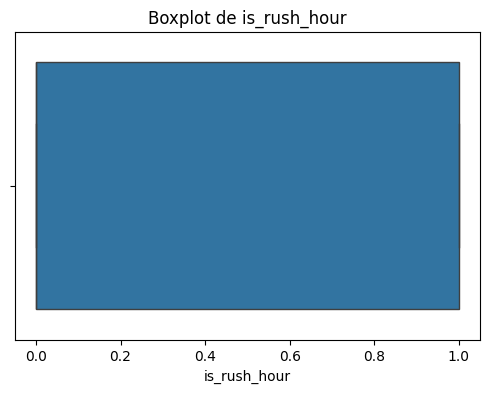

In [16]:
# Hist
df_train[numeric_cols].hist(figsize=(15, 10), bins=30)
plt.suptitle("Distribuição das Features Numéricas")
plt.show()

# KDE individual e boxplot
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.kdeplot(df_train[col], fill=True)
    plt.title(f"Distribuição (KDE) de {col}")
    plt.show()


    plt.figure(figsize=(6,4))
    sns.boxplot(x=df_train[col])
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.show()

Analisar tabelas com maior probabilidade de outliers

In [17]:
max_val = df_train['AVERAGE_TIME_DIFF'].max()

subset = df_train[df_train['AVERAGE_TIME_DIFF'] == max_val]

subset[['AVERAGE_TIME_DIFF', 'AVERAGE_SPEED_DIFF']]

,AVERAGE_TIME_DIFF,AVERAGE_SPEED_DIFF
3259,296.5,Very_High


In [18]:
subset['AVERAGE_SPEED_DIFF'].value_counts()

AVERAGE_SPEED_DIFF
Very_High    1
Name: count, dtype: int64

In [19]:
threshold = df_train['AVERAGE_TIME_DIFF'].quantile(0.99)

subset = df_train[df_train['AVERAGE_TIME_DIFF'] >= threshold]

subset['AVERAGE_SPEED_DIFF'].value_counts(normalize=True)

AVERAGE_SPEED_DIFF
Very_High    0.550725
High         0.449275
Name: proportion, dtype: float64

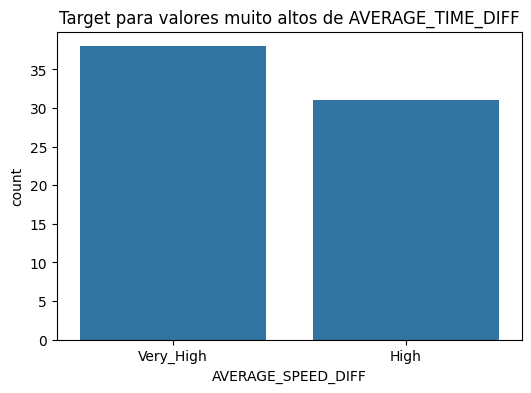

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(data=subset, x='AVERAGE_SPEED_DIFF')
plt.title("Target para valores muito altos de AVERAGE_TIME_DIFF")
plt.show()

**Binning**

In [21]:
from sklearn.preprocessing import KBinsDiscretizer
# Bins
# | AVERAGE_FREE_FLOW_SPEED 
# | AVERAGE_TIME_DIFF 
# | AVERAGE_FREE_FLOW_TIME 
# | AVERAGE_TEMPERATURE 
# | AVERAGE_ATMOSP_PRESSURE 
# | AVERAGE_HUMIDITY -> removi devido aos bins com largura mínima
# | AVERAGE_WIND_SPEED

cols_to_bin = [
    'AVERAGE_FREE_FLOW_SPEED',
    'AVERAGE_TIME_DIFF',
    'AVERAGE_FREE_FLOW_TIME',
    'AVERAGE_TEMPERATURE',
    'AVERAGE_ATMOSP_PRESSURE',
    'AVERAGE_WIND_SPEED',
]

kbin = KBinsDiscretizer(
    n_bins=4,
    encode='ordinal',     
    strategy='quantile',
    quantile_method='averaged_inverted_cdf' # tive de add para não dar warning
)

df_train_binned = df_train.copy()
df_test_binned  = df_test.copy()

# Fit com o de treino e aplicar ao de teste
df_train_binned[cols_to_bin] = kbin.fit_transform(
    df_train[cols_to_bin]
)
df_test_binned[cols_to_bin] = kbin.transform(
    df_test[cols_to_bin]
)

**Relations**

<Axes: >

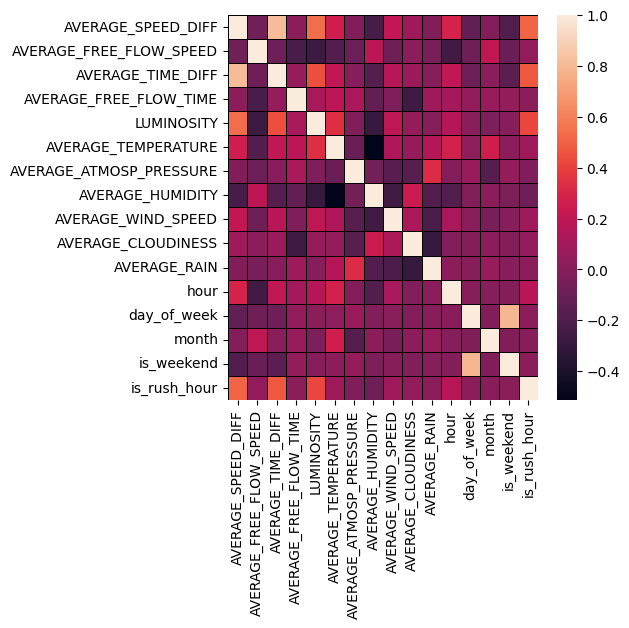

In [22]:

# Criar uma cópia apenas para análise
df_temp = df_train.copy()

""" le_speed = LabelEncoder()
df_temp["AVERAGE_SPEED_DIFF"] = le_speed.fit_transform(df_temp["AVERAGE_SPEED_DIFF"])
 """
from sklearn.preprocessing import OrdinalEncoder

ord_encoder = OrdinalEncoder(categories=[["None", "Low", "Medium", "High", "Very_High"]])

df_temp["AVERAGE_SPEED_DIFF"] = ord_encoder.fit_transform(df_temp[["AVERAGE_SPEED_DIFF"]])
df_temp["AVERAGE_SPEED_DIFF"] = df_temp["AVERAGE_SPEED_DIFF"].astype(int)

fig = plt.figure(figsize=(5,5))
corre = df_temp.corr(method='pearson')
sns.heatmap(corre,linecolor='black', linewidths=0.5)

<Axes: >

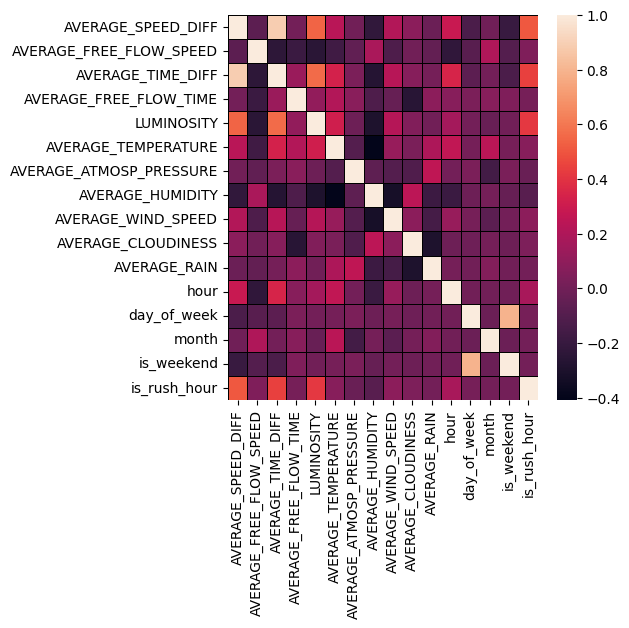

In [23]:
# Criar uma cópia apenas para análise
df_temp = df_train_binned.copy()

""" le_speed = LabelEncoder()
df_temp["AVERAGE_SPEED_DIFF"] = le_speed.fit_transform(df_temp["AVERAGE_SPEED_DIFF"])
 """
from sklearn.preprocessing import OrdinalEncoder

ord_encoder = OrdinalEncoder(categories=[["None", "Low", "Medium", "High", "Very_High"]])

df_temp["AVERAGE_SPEED_DIFF"] = ord_encoder.fit_transform(df_temp[["AVERAGE_SPEED_DIFF"]])
df_temp["AVERAGE_SPEED_DIFF"] = df_temp["AVERAGE_SPEED_DIFF"].astype(int)

fig = plt.figure(figsize=(5,5))
corre = df_temp.corr(method='pearson')
sns.heatmap(corre,linecolor='black', linewidths=0.5)

In [24]:

target_corr = corre["AVERAGE_SPEED_DIFF"].drop("AVERAGE_SPEED_DIFF")


target_corr_sorted = target_corr.abs().sort_values(ascending=False)

print("Correlação ordenada com o target AVERAGE_SPEED_DIFF:\n")
print(target_corr_sorted)

Correlação ordenada com o target AVERAGE_SPEED_DIFF:

AVERAGE_TIME_DIFF          0.887194
LUMINOSITY                 0.538359
is_rush_hour               0.506868
hour                       0.285956
AVERAGE_TEMPERATURE        0.234162
AVERAGE_HUMIDITY           0.224832
AVERAGE_WIND_SPEED         0.212006
is_weekend                 0.197382
day_of_week                0.129614
AVERAGE_CLOUDINESS         0.086954
AVERAGE_FREE_FLOW_SPEED    0.071254
AVERAGE_RAIN               0.018384
AVERAGE_FREE_FLOW_TIME     0.007599
month                      0.005785
AVERAGE_ATMOSP_PRESSURE    0.001920
Name: AVERAGE_SPEED_DIFF, dtype: float64


As 3 primeiras parecem ser as features mais fortes para o modelo

In [25]:
corre

,AVERAGE_SPEED_DIFF,AVERAGE_FREE_FLOW_SPEED,AVERAGE_TIME_DIFF,AVERAGE_FREE_FLOW_TIME,LUMINOSITY,AVERAGE_TEMPERATURE,AVERAGE_ATMOSP_PRESSURE,AVERAGE_HUMIDITY,AVERAGE_WIND_SPEED,AVERAGE_CLOUDINESS,AVERAGE_RAIN,hour,day_of_week,month,is_weekend,is_rush_hour
AVERAGE_SPEED_DIFF,1.000000,-0.071254,0.887194,0.007599,0.538359,0.234162,0.001920,-0.224832,0.212006,0.086954,-0.018384,0.285956,-0.129614,-0.005785,-0.197382,0.506868
AVERAGE_FREE_FLOW_SPEED,-0.071254,1.000000,-0.239563,-0.188985,-0.250320,-0.171320,-0.055217,0.180959,-0.120765,0.001246,-0.045813,-0.229335,-0.085631,0.201283,-0.096316,0.043869
AVERAGE_TIME_DIFF,0.887194,-0.239563,1.000000,0.134013,0.562088,0.331015,0.032982,-0.266446,0.228803,0.067323,0.012398,0.343320,-0.070878,0.008592,-0.131313,0.439160
AVERAGE_FREE_FLOW_TIME,0.007599,-0.188985,0.134013,1.000000,0.108606,0.210906,0.078522,-0.119699,-0.034141,-0.258035,0.088198,0.073122,0.037348,0.071147,0.045398,0.017516
LUMINOSITY,0.538359,-0.250320,0.562088,0.108606,1.000000,0.313017,-0.013117,-0.292645,0.223868,0.051703,0.000502,0.166596,0.007635,-0.032471,0.002854,0.416982
AVERAGE_TEMPERATURE,0.234162,-0.171320,0.331015,0.210906,0.313017,1.000000,-0.095625,-0.407876,0.125380,0.030066,0.194029,0.260052,0.014624,0.238735,0.018823,0.074210
AVERAGE_ATMOSP_PRESSURE,0.001920,-0.055217,0.032982,0.078522,-0.013117,-0.095625,1.000000,-0.066323,-0.097535,-0.112577,0.256108,0.007299,0.036252,-0.159511,0.030787,-0.024844
AVERAGE_HUMIDITY,-0.224832,0.180959,-0.266446,-0.119699,-0.292645,-0.407876,-0.066323,1.000000,-0.325306,0.242553,-0.182865,-0.191897,-0.014953,0.015225,-0.035638,-0.086514
AVERAGE_WIND_SPEED,0.212006,-0.120765,0.228803,-0.034141,0.223868,0.125380,-0.097535,-0.325306,1.000000,0.084182,-0.151048,0.124264,0.019307,-0.074216,0.007667,0.089695
AVERAGE_CLOUDINESS,0.086954,0.001246,0.067323,-0.258035,0.051703,0.030066,-0.112577,0.242553,0.084182,1.000000,-0.295780,-0.015274,-0.009371,0.014561,-0.013218,0.041715


### **Modeling**

Select features and target

In [26]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

In [27]:
X_train = df_train_binned.drop(columns=["AVERAGE_SPEED_DIFF"])
y_train = df_train_binned["AVERAGE_SPEED_DIFF"]

In [28]:
X_test = df_test_binned

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

**Grid Search**

Hyperparameter Tuning with Grid Search - Check what is the best estimator and parameters

In [29]:
rf = RandomForestClassifier(random_state=2022)

param_grid = {
    'n_estimators': [100, 200],         # Number of trees in the forest
    'max_depth': [10, 20, None],        # Maximum depth of the tree
    'min_samples_split': [2, 5],        # Minimum samples required to split an internal node
    'criterion': ['gini', 'entropy']    # Gini or Entropy
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,          # 3-Fold Cross Validation (speeds it up compared to 5)
    verbose=0,
    n_jobs=-1      # Use all processor cores
)

grid_rf.fit(X_train, y_train)

print("Best Parameters:", grid_rf.best_params_)
print("Best CV Accuracy:", grid_rf.best_score_)

best_rf = grid_rf.best_estimator_

Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best CV Accuracy: 0.7404567970923687


**Validation Block**

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Cópias
X_val_copy = X_train.copy()
y_val_copy = y_train.copy()

# criar conjunto de val
X_tr, X_val, y_tr, y_val = train_test_split(
    X_val_copy, y_val_copy, test_size=0.2, random_state=2022, stratify=y_val_copy
)

# Treinar modelo só para validar
clf_val = best_rf # Validar com o melhor modelo dado pelo GridSearch
clf_val.fit(X_tr, y_tr)

# Prever na validação
val_preds = clf_val.predict(X_val)

# Mostrar accuracy
print("Validation Accuracy:", accuracy_score(y_val, val_preds))
print("\nClassification Report:\n", classification_report(y_val, val_preds))


Validation Accuracy: 0.7373440939104916

Classification Report:
               precision    recall  f1-score   support

        High       0.69      0.77      0.73       213
         Low       0.62      0.49      0.54       284
      Medium       0.73      0.75      0.74       330
        None       0.81      0.88      0.84       440
   Very_High       0.82      0.74      0.78        96

    accuracy                           0.74      1363
   macro avg       0.73      0.72      0.73      1363
weighted avg       0.73      0.74      0.73      1363



**Predict**

Predict on test set

In [31]:
clf = best_rf
clf.fit(X_train, y_train)

,n_estimators,200
,criterion,'entropy'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [32]:
preds = clf.predict(X_test)

Create csv

In [33]:
submission = pd.DataFrame({
    "RowId": range(1, len(preds)+1),
    "Speed_Diff": preds
})

submission.to_csv("../../results/RandomForest/rf4grid.csv", index=False)
submission.head()

,RowId,Speed_Diff
0,1,None
1,2,Medium
2,3,None
3,4,High
4,5,Low
